# Amenity-specific distance differentials


In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd() / "figure-reproduction", Path.cwd().parent]
repro_dir = next(
    (path.resolve() for path in candidates if (path / "src").is_dir() and (path / "data").is_dir()),
    None,
)
if repro_dir is None:
    raise FileNotFoundError("Run this notebook from the repository, figure-reproduction, or notebooks directory.")
sys.path.insert(0, str(repro_dir / "src"))

from figure_style import (
    DATA_DIR,
    OUTPUT_DIR,
    close_and_report,
    configure_style,
    figure_size,
    finish_axes,
    save_figure,
)


1 extra bytes in post.stringData array


rendered pixels: 1417 x 1134
saved: /Users/silver/Desktop/finland-mobility/figure-reproduction/output/amenity_distance_differentials.png
saved: /Users/silver/Desktop/finland-mobility/figure-reproduction/output/amenity_distance_differentials.pdf


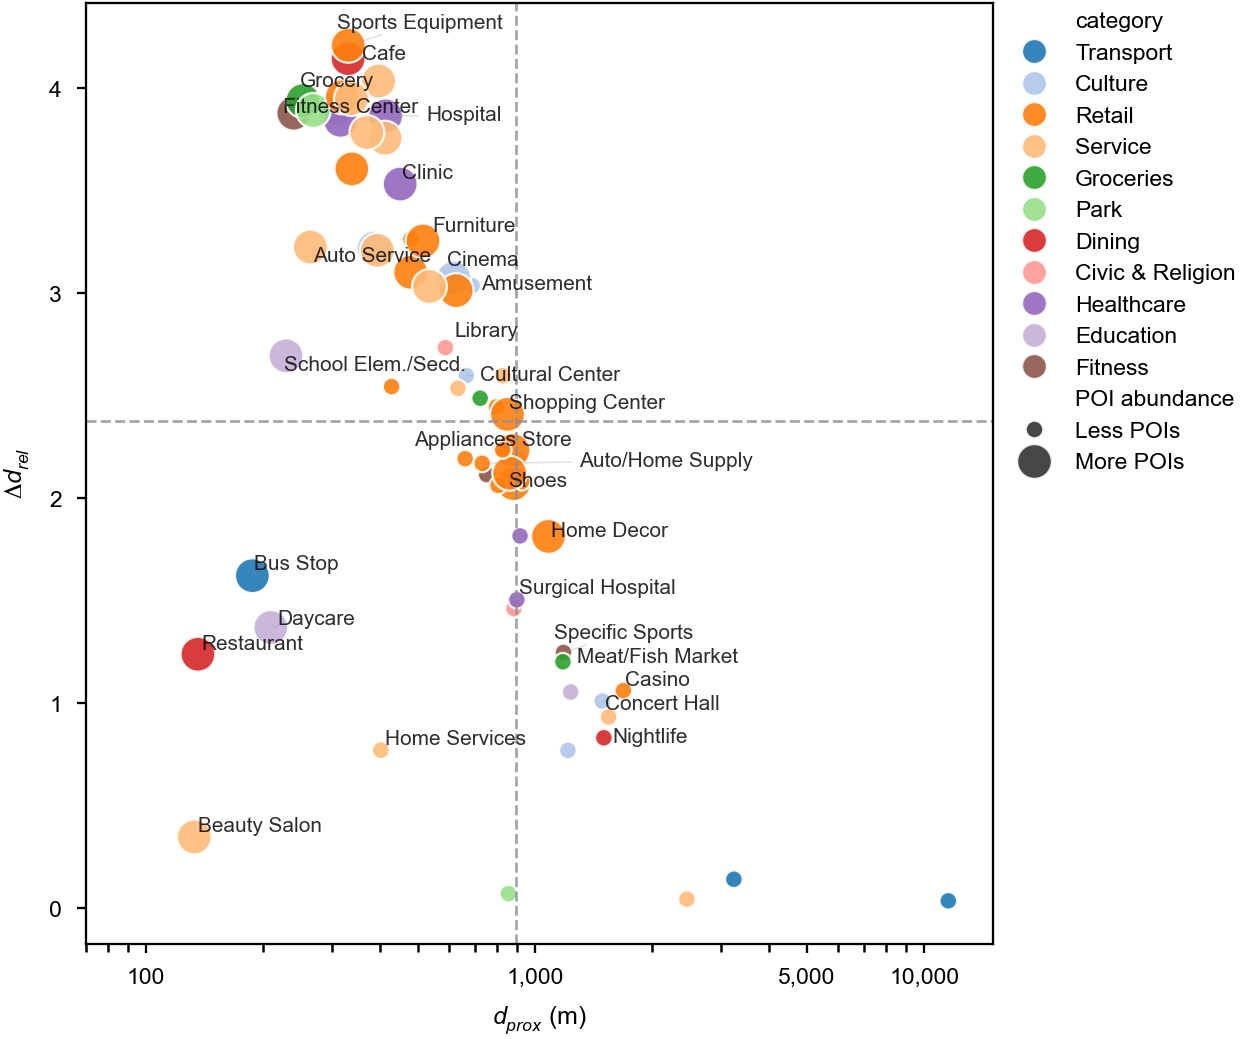

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from adjustText import adjust_text

EXPORT_PROFILE = "final"
configure_style(EXPORT_PROFILE)

data = pd.read_parquet(DATA_DIR / "amenity_distance_differentials.parquet")
poi_count_median = data["poi_count"].median()
data["POI abundance"] = data["poi_count"].ge(poi_count_median).map({False: "Less POIs", True: "More POIs"})
category_order = [
    "Transport", "Culture", "Retail", "Service", "Groceries", "Park",
    "Dining", "Civic & Religion", "Healthcare", "Education", "Fitness",
]
tab20 = mpl.colormaps["tab20"]
category_palette = {category: tab20(index) for index, category in enumerate(category_order)}

fig, ax = plt.subplots(figsize=figure_size("amenity_distance_differentials"))
fig.subplots_adjust(left=0.12, right=0.76, bottom=0.13, top=0.96)
sns.scatterplot(
    ax=ax, data=data, x="d_prox", y="delta_d_rel",
    size="POI abundance", size_order=["Less POIs", "More POIs"], sizes={"Less POIs": 18, "More POIs": 70},
    hue="category", hue_order=category_order, palette=category_palette,
    alpha=0.9, edgecolor="white", linewidth=0.55, legend="brief",
)
ax.set_xscale("log")
ax.set_xlim(70, 15_000)
ax.axhline(data["delta_d_rel"].mean(), color="#8A8F98", linestyle="--", linewidth=0.65, alpha=0.8)
ax.axvline(data["d_prox"].mean(), color="#8A8F98", linestyle="--", linewidth=0.65, alpha=0.8)
ax.set_xlabel(r"$d_{prox}$ (m)")
ax.set_ylabel(r"$\Delta d_{rel}$")
ax.set_xticks([100, 1000, 5000, 10000])
ax.set_xticklabels(["100", "1,000", "5,000", "10,000"])
for spine in ax.spines.values():
    spine.set_visible(True)

label_classes = {
    "Sports Equipment", "Cafe", "Grocery", "Fitness Center", "Hospital",
    "Clinic", "Furniture", "Cinema", "Amusement", "Auto Service", "Library",
    "Cultural Center", "Shopping Center", "School Elem./Secd.", "Auto/Home Supply",
    "Appliances Store", "Shoes", "Bus Stop", "Home Decor", "Daycare", "Restaurant",
    "Surgical Hospital", "Specific Sports", "Meat/Fish Market", "Casino",
    "Concert Hall", "Nightlife", "Home Services", "Beauty Salon",
}
texts = [
    ax.text(row.d_prox, row.delta_d_rel, row.original_class, fontsize=5, alpha=0.82)
    for row in data.itertuples()
    if row.original_class in label_classes
]
adjust_text(
    texts, ax=ax,
    arrowprops={"arrowstyle": "-", "color": "#999999", "alpha": 0.3, "linewidth": 0.35},
)
sns.move_legend(
    ax, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False,
    title=None, borderaxespad=0,
)
paths = save_figure(fig, "amenity_distance_differentials", EXPORT_PROFILE)
close_and_report(fig, paths)
